## Лабораторна робота №2

#### Виконав: студент ОІ-32    
#### *Криворучко Микола*
#### Прийняла: асистентка кафедри АСУ
#### *Ткачук К. І.*

**Тема**: Застосування методів кластеризації та зменшення розмірності.

**Мета**: Ознайомитися з алгоритмами кластеризації K-Means та Fuzzy C-Means. Вивчити вплив зменшення розмірності даних за допомогою PCA на результати кластеризації. Порівняти отримані кластери за допомогою метрик (наприклад, silhouette score). Розробити програмне рішення на Python з використанням бібліотек scikit-learn та scikit-fuzzy.

* 1. [Підготовка даних](#prep)
* 2. [Кластеризація у вихідному просторі (без зменшення розмірності)](#clustering)
* 3. [Зменшення розмірності за допомогою PCA (до 2–3 компонент)](#pca)
* 4. [Зменшення розмірності за допомогою PCA (до 4–5 компонент)](#pca_two)
* 5. [Візуалізація результатів](#visualization)
* 6. [Аналіз та висновки](#analysis)

<a id="prep"></a>
### 1. Підготовка даних

Імпортую потрібні бібліотеки та завантажую дані.

In [1]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 
from mpl_toolkits.mplot3d import Axes3D 

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA 
from sklearn.manifold import TSNE
import umap 

from sklearn.cluster import KMeans, DBSCAN 
from sklearn.mixture import GaussianMixture 
import skfuzzy as fuzz 

from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score
)

sns.set_theme(style="whitegrid")

In [2]:
data = pd.read_csv("./credit_card.csv")

data.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


* **CUST_ID**: Ідентифікатор власника кредитної картки (Категоріальна змінна).
  
* **BALANCE**: Сума залишку на рахунку, доступна для здійснення покупок.
* **BALANCE_FREQUENCY**: Як часто оновлюється баланс, показник від 0 до 1 (1 = часто оновлюється, 0 = рідко оновлюється).
* **PURCHASES**: Загальна сума покупок, здійснених з рахунку.
* **ONEOFF_PURCHASES**: Сума покупок, здійснених одним платежем (за один раз, без розстрочки).
* **INSTALLMENTS_PURCHASES**: Сума покупок, здійснених у розстрочку.
* **CASH_ADVANCE**: Сума готівкового авансу (зняття готівки в кредит), отриманого користувачем.
* **PURCHASES_FREQUENCY**: Як часто здійснюються покупки, показник від 0 до 1 (1 = купують часто, 0 = купують рідко).
* **ONEOFFPURCHASESFREQUENCY**: Як часто відбуваються покупки одним платежем (1 = часто, 0 = рідко).
* **PURCHASESINSTALLMENTSFREQUENCY**: Як часто відбуваються покупки у розстрочку (1 = часто, 0 = рідко).
* **CASHADVANCEFREQUENCY**: Як часто користувач бере готівковий аванс (знімає кредитні кошти готівкою).
* **CASHADVANCETRX**: Кількість транзакцій зі зняття готівкового авансу.
* **PURCHASES_TRX**: Кількість здійснених транзакцій покупок.
* **CREDIT_LIMIT**: Кредитний ліміт картки користувача.
* **PAYMENTS**: Загальна сума платежів (погашення кредиту), здійснених користувачем.
* **MINIMUM_PAYMENTS**: Мінімальна сума платежів, здійснених користувачем.
* **PRCFULLPAYMENT**: Відсоток платежів, якими користувач повністю погасив свій борг.
* **TENURE**: Термін користування кредитною карткою (у місяцях).

In [3]:
data.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [4]:
data.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

Перевіряю наявність пропусків; при необхідності заповнюю медіаною (стійкіше до викидів ніж середнє).

In [5]:
data.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

<Axes: xlabel='CREDIT_LIMIT', ylabel='Count'>

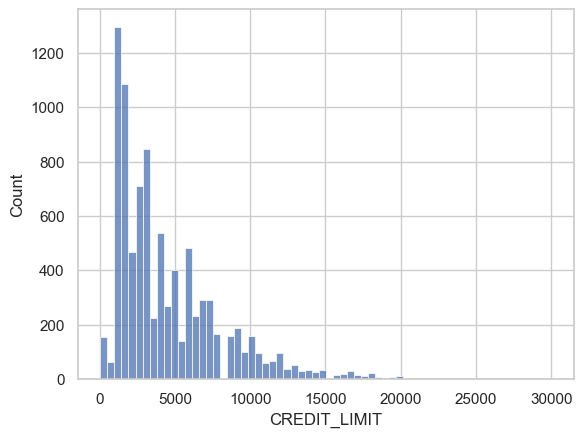

In [6]:
sns.histplot(data["CREDIT_LIMIT"])

In [7]:
data["CREDIT_LIMIT"].median()

3000.0

In [8]:
data["CREDIT_LIMIT"].mean()

4494.449450364621

In [9]:
index = data[data["CREDIT_LIMIT"].isna() == True]["CREDIT_LIMIT"].index

data.loc[index, "CREDIT_LIMIT"] = data["CREDIT_LIMIT"].median()

<Axes: xlabel='MINIMUM_PAYMENTS', ylabel='Count'>

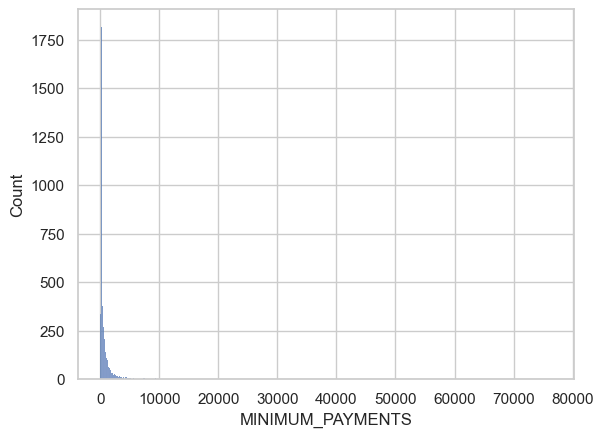

In [10]:
sns.histplot(data["MINIMUM_PAYMENTS"])

In [11]:
data["MINIMUM_PAYMENTS"].mean()

864.2065423050828

In [12]:
data["MINIMUM_PAYMENTS"].median()

312.343947

In [13]:
index = data[data["MINIMUM_PAYMENTS"].isna() == True].index

data.loc[index, "MINIMUM_PAYMENTS"] = data["MINIMUM_PAYMENTS"].median()

In [14]:
data.isna().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

Також видалю непотрібну колонку "CUST_ID":

In [15]:
data = data.drop(columns="CUST_ID")

Проводжу масштабування даних:

In [16]:
labels = data.columns

scaler = StandardScaler()

data = pd.DataFrame(
    data = scaler.fit_transform(data),
    columns=labels
)

data.head()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


**Обраний підхід до нормалізації:** використано **StandardScaler** (стандартизація: нульове середнє, одинична дисперсія). Це обґрунтовано тим, що (1) алгоритми кластеризації (K-Means, GMM, DBSCAN) опираються на відстані між точками — без масштабування ознаки з більшим діапазоном (наприклад, суми покупок) домінували б над іншими; (2) PCA орієнтується на коваріацію, тому стандартизовані ознаки дають збалансований внесок у головні компоненти; (3) MinMaxScaler більш чутливий до викидів, тоді як у наших даних є екстремальні значення (баланси, кредитні ліміти).

<a id="clustering"></a>
### 2. Кластеризація у вихідному просторі (без зменшення розмірності)

Порівнюються K-Means, Fuzzy C-Means, GMM та DBSCAN на вихідних даних. Для кожного методу — підбір параметрів (п. 2 методички), кластеризація та оцінка (silhouette score, Davies-Bouldin, Calinski-Harabasz, FPC для FCM).

Напишу допоміжні функції для подальшої роботи:

In [17]:
def evaluate_clustering(X, labels, model_name, fuzzy_fpc=None):
    if len(set(labels)) <= 1 or (len(set(labels)) == 2 and -1 in labels):
        print(f"[{model_name}] Недостатньо кластерів для обчислення метрик.")
        return None

    mask = labels != -1
    X_filtered = X[mask]
    labels_filtered = labels[mask]
    
    metrics = {
        "Model": model_name,
        "Silhouette": silhouette_score(X_filtered, labels_filtered),
        "Davies-Bouldin": davies_bouldin_score(X_filtered, labels_filtered),
        "Calinski-Harabasz": calinski_harabasz_score(X_filtered, labels_filtered)
    }
    
    if fuzzy_fpc is not None:
        metrics["FPC"] = fuzzy_fpc
        
    return metrics

def run_fuzzy_cmeans(X, n_clusters, m=2.0):
    X_t = X.T 
    
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        X_t, c=n_clusters, m=m, error=0.005, maxiter=1000, init=None, seed=42 
    )
    
    hard_labels = np.argmax(u, axis=0) 
    
    return hard_labels, u, fpc

In [18]:
def optimize_kmeans(X, max_k=10):
    inertias = []
    sil_scores = []
    K = list(range(2, max_k + 1))
    
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X)
        inertias.append(kmeans.inertia_)
        sil_scores.append(silhouette_score(X, kmeans.labels_))
    
    best_k = K[np.argmax(sil_scores)]
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(K, inertias, 'bo-', label='Inertia')
    ax1.set_xlabel('Кількість кластерів (k)')
    ax1.set_ylabel('Inertia (Сума квадратів відстаней)', color='b')
    ax2 = ax1.twinx()
    ax2.plot(K, sil_scores, 'ro-', label='Silhouette Score')
    ax2.set_ylabel('Silhouette Score', color='r')
    ax2.axvline(x=best_k, color='gray', linestyle='--', alpha=0.7, label=f'Оптимальне k={best_k}')
    plt.title('Оптимізація K-Means (Метод ліктя та Silhouette)')
    plt.tight_layout()
    plt.show()
    return best_k

def optimize_fcm(X, max_k=10):
    """Оптимізація Fuzzy C-Means: підбір кількості кластерів за FPC та Silhouette."""
    k_range = list(range(2, max_k + 1))
    fpc_scores = []
    sil_scores = []
    for k in k_range:
        labels_fcm, _, fpc = run_fuzzy_cmeans(X, n_clusters=k)
        fpc_scores.append(fpc)
        mask = labels_fcm >= 0
        if len(np.unique(labels_fcm[mask])) > 1:
            sil_scores.append(silhouette_score(X[mask], labels_fcm[mask]))
        else:
            sil_scores.append(0)
    best_k = k_range[np.argmax(fpc_scores)]
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(k_range, fpc_scores, 'bo-', label='FPC')
    ax1.set_xlabel('Кількість кластерів (c)')
    ax1.set_ylabel('Fuzzy Partition Coefficient', color='b')
    ax2 = ax1.twinx()
    ax2.plot(k_range, sil_scores, 'ro-', label='Silhouette')
    ax2.set_ylabel('Silhouette Score', color='r')
    ax2.axvline(x=best_k, color='gray', linestyle='--', alpha=0.7, label=f'Оптимальне c={best_k}')
    plt.title('Оптимізація Fuzzy C-Means (FPC та Silhouette)')
    plt.tight_layout()
    plt.show()
    return best_k

def optimize_gmm(X, max_components=10):
    bics = []
    aics = []
    N = list(range(2, max_components + 1))
    for n in N:
        gmm = GaussianMixture(n_components=n, random_state=42).fit(X)
        bics.append(gmm.bic(X))
        aics.append(gmm.aic(X))
    best_n = N[np.argmin(bics)]
    plt.figure(figsize=(8, 4))
    plt.plot(N, bics, 'o-', label='BIC')
    plt.plot(N, aics, 's-', label='AIC')
    plt.axvline(x=best_n, color='gray', linestyle='--', alpha=0.7, label=f'Оптимальне n={best_n}')
    plt.xlabel('Кількість компонент')
    plt.ylabel('Інформаційний критерій')
    plt.title('Оптимізація GMM (BIC та AIC)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return best_n

def optimize_dbscan(X, eps_range=None, min_samples=5):
    """Оптимізація DBSCAN: підбір eps за кількістю кластерів та Silhouette."""
    if eps_range is None:
        eps_range = np.linspace(0.3, 1.5, 15)
    n_clusters_list = []
    n_noise_list = []
    sil_list = []
    for eps in eps_range:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        labs = db.labels_
        n_clusters = len(set(labs)) - (1 if -1 in labs else 0)
        n_noise = (labs == -1).sum()
        n_clusters_list.append(n_clusters)
        n_noise_list.append(n_noise)
        mask = labs != -1
        if n_clusters >= 2 and mask.sum() > 0:
            sil_list.append(silhouette_score(X[mask], labs[mask]))
        else:
            sil_list.append(np.nan)
    valid = np.isfinite(sil_list)
    best_idx = np.nanargmax(sil_list) if np.any(valid) else len(eps_range) // 2
    best_eps = eps_range[best_idx]
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(eps_range, n_clusters_list, 'bo-', label='Кількість кластерів')
    ax1.set_xlabel('eps')
    ax1.set_ylabel('Кількість кластерів', color='b')
    ax2 = ax1.twinx()
    ax2.plot(eps_range, sil_list, 'ro-', label='Silhouette')
    ax2.set_ylabel('Silhouette Score', color='r')
    ax2.axvline(x=best_eps, color='gray', linestyle='--', alpha=0.7, label=f'Оптимальне eps={best_eps:.2f}')
    plt.title('Оптимізація DBSCAN (eps)')
    plt.tight_layout()
    plt.show()
    return best_eps, min_samples

In [19]:
def plot_clusters_2d(X_pca, labels, title, centers=None):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="viridis", s=60) 
    
    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Центроїди')
        
    plt.title(title) 
    plt.xlabel("Компонента 1") 
    plt.ylabel("Компонента 2") 
    plt.legend(title="Кластер", bbox_to_anchor=(1.05, 1), loc='upper left') 
    plt.tight_layout()
    plt.show()

def plot_clusters_3d(X_pca, labels, title):
    """Побудова 3D графіка кластерів (якщо PCA має 3 компоненти)."""
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
                         c=labels, cmap='viridis', s=60)
    
    ax.set_title(title)
    ax.set_xlabel('Компонента 1')
    ax.set_ylabel('Компонента 2')
    ax.set_zlabel('Компонента 3')
    
    legend = ax.legend(*scatter.legend_elements(), title="Кластери")
    ax.add_artist(legend)
    plt.show()

In [20]:
pca_viz = PCA(n_components=2, random_state=42)
data_2d_viz = pca_viz.fit_transform(data)

#### 2.1 K-Means

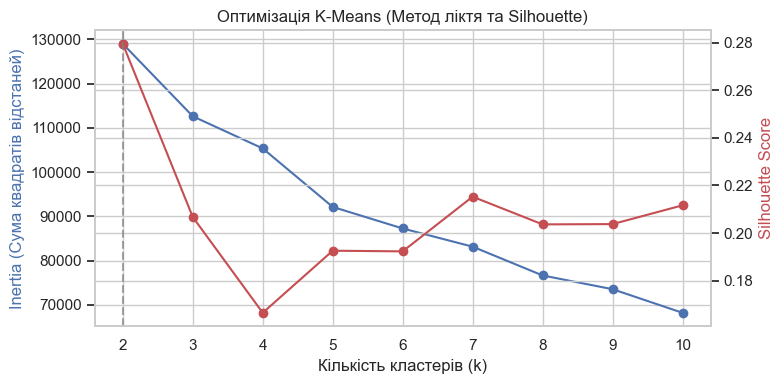

Обрано k = 2. Silhouette: 0.2795, Davies-Bouldin: 1.8009



/Users/nickol/miniforge3/envs/ml-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


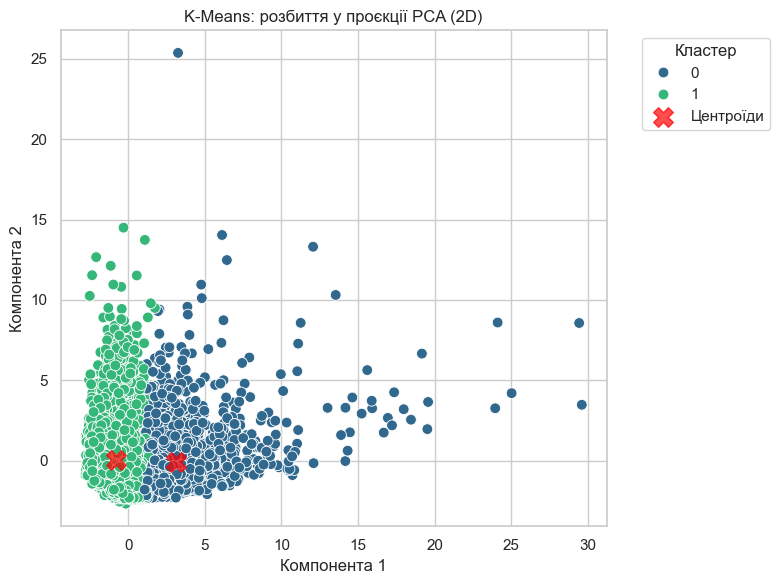

In [21]:
all_metrics = []

best_k_kmeans = optimize_kmeans(data)
kmeans = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init='auto')
labels_kmeans = kmeans.fit_predict(data)
metrics_kmeans = evaluate_clustering(data, labels_kmeans, "K-Means")
all_metrics.append(metrics_kmeans)
print(f"Обрано k = {best_k_kmeans}. Silhouette: {metrics_kmeans['Silhouette']:.4f}, Davies-Bouldin: {metrics_kmeans['Davies-Bouldin']:.4f}\n")
centers_2d_kmeans = pca_viz.transform(kmeans.cluster_centers_)
plot_clusters_2d(data_2d_viz, labels_kmeans, "K-Means: розбиття у проєкції PCA (2D)", centers=centers_2d_kmeans) 

#### 2.2 Fuzzy C-Means (FCM)

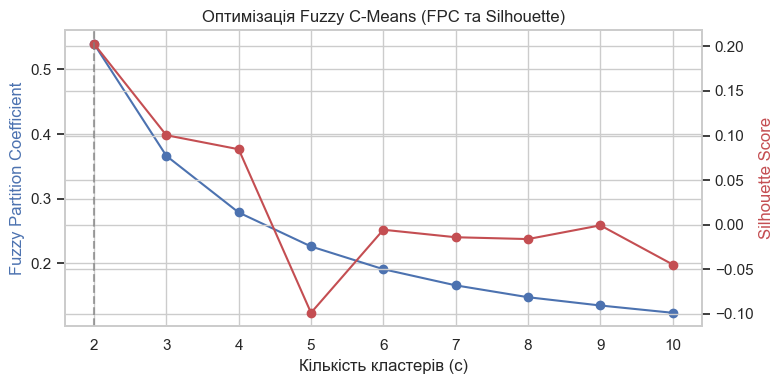

Обрано c = 2. Silhouette: 0.2029, FPC: 0.5395



/Users/nickol/miniforge3/envs/ml-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


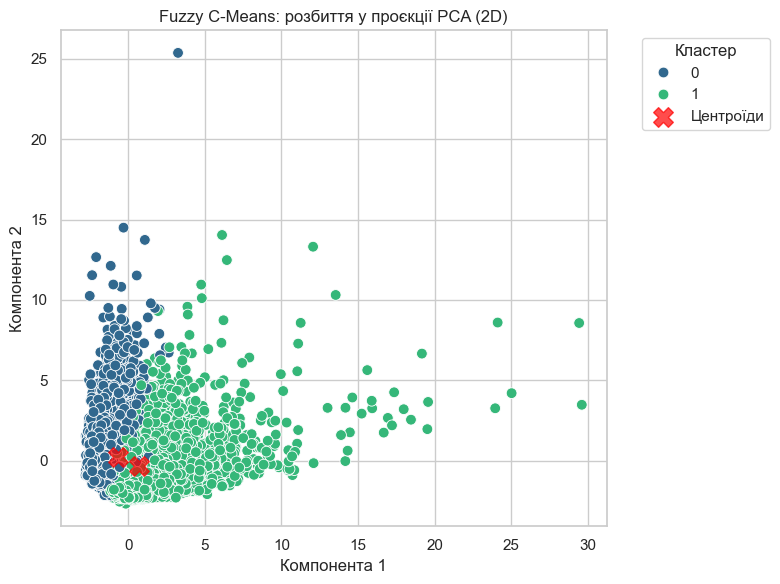

In [22]:
best_c_fcm = optimize_fcm(data)
labels_fcm, u_matrix, fpc_score = run_fuzzy_cmeans(data, n_clusters=best_c_fcm)
metrics_fcm = evaluate_clustering(data, labels_fcm, "Fuzzy C-Means", fuzzy_fpc=fpc_score)
all_metrics.append(metrics_fcm)
print(f"Обрано c = {best_c_fcm}. Silhouette: {metrics_fcm['Silhouette']:.4f}, FPC: {metrics_fcm['FPC']:.4f}\n")
fcm_centers_highd = (data.values.T @ (u_matrix ** 2).T / np.sum(u_matrix ** 2, axis=1)).T
fcm_centers_2d = pca_viz.transform(fcm_centers_highd)
plot_clusters_2d(data_2d_viz, labels_fcm, "Fuzzy C-Means: розбиття у проєкції PCA (2D)", centers=fcm_centers_2d)

#### 2.3. Gaussian Mixture Model (GMM)

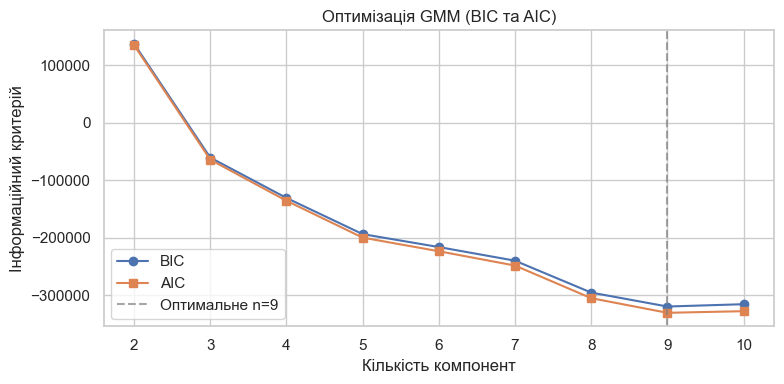

Обрано n_components = 9. Silhouette: 0.0248



/Users/nickol/miniforge3/envs/ml-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


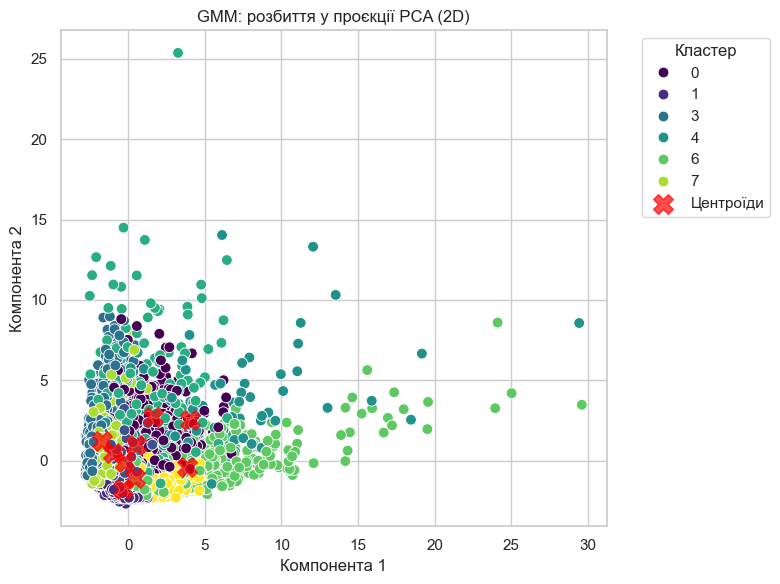

In [23]:
best_n_gmm = optimize_gmm(data)
gmm = GaussianMixture(n_components=best_n_gmm, random_state=42)
gmm.fit(data)
labels_gmm = gmm.predict(data)
proba_gmm = gmm.predict_proba(data)
metrics_gmm = evaluate_clustering(data, labels_gmm, "GMM")
all_metrics.append(metrics_gmm)
print(f"Обрано n_components = {best_n_gmm}. Silhouette: {metrics_gmm['Silhouette']:.4f}\n")
gmm_centers_2d = pca_viz.transform(gmm.means_)
plot_clusters_2d(data_2d_viz, labels_gmm, "GMM: розбиття у проєкції PCA (2D)", centers=gmm_centers_2d)

#### 2.4 DBSCAN

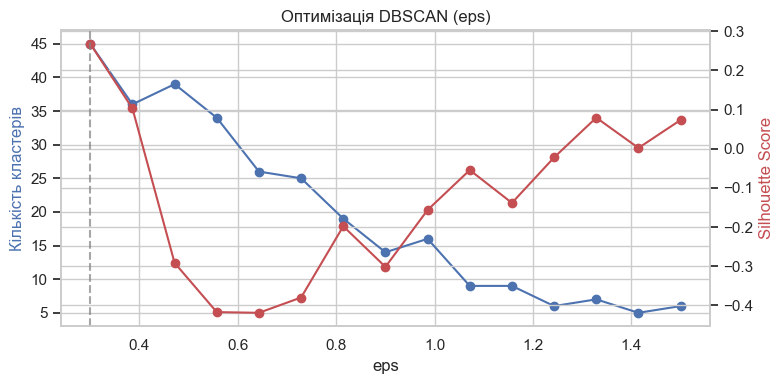

Обрано eps = 0.300, min_samples = 5. Шумових точок: 8090 з 8950
Silhouette (без шуму): 0.2678



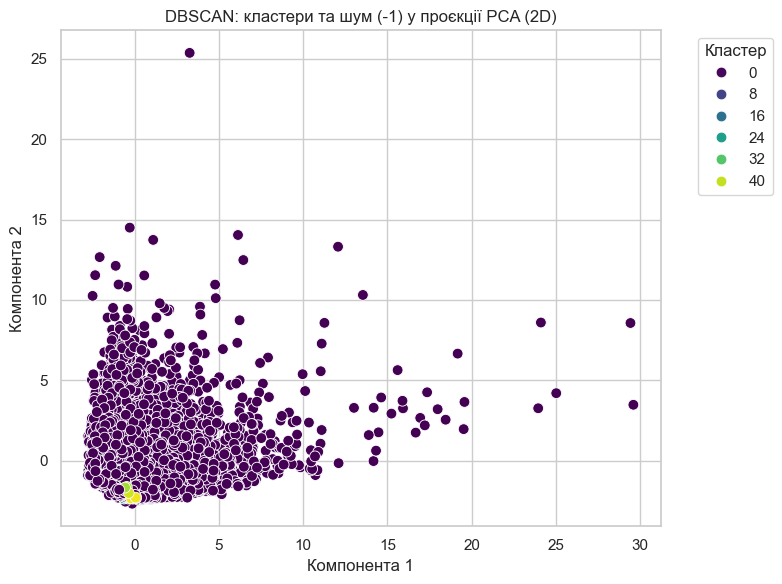

In [24]:
best_eps_db, best_min_samp_db = optimize_dbscan(data)
dbscan = DBSCAN(eps=best_eps_db, min_samples=best_min_samp_db)
labels_dbscan = dbscan.fit_predict(data)
n_noise = (labels_dbscan == -1).sum()
print(f"Обрано eps = {best_eps_db:.3f}, min_samples = {best_min_samp_db}. Шумових точок: {n_noise} з {len(labels_dbscan)}")
metrics_dbscan = evaluate_clustering(data, labels_dbscan, "DBSCAN")
if metrics_dbscan:
    all_metrics.append(metrics_dbscan)
    print(f"Silhouette (без шуму): {metrics_dbscan['Silhouette']:.4f}\n")
else:
    print("Метрики для DBSCAN недоступні (замало кластерів або забагато шуму).\n")
plot_clusters_2d(data_2d_viz, labels_dbscan, "DBSCAN: кластери та шум (-1) у проєкції PCA (2D)")

In [25]:
results_df = pd.DataFrame(all_metrics).set_index("Model")
display(results_df)

,Silhouette,Davies-Bouldin,Calinski-Harabasz,FPC
Model,,,,
K-Means,0.279540,1.800894,1609.609316,NaN
Fuzzy C-Means,0.202929,1.922240,1689.602699,0.539522
GMM,0.024787,3.057064,413.377026,NaN
DBSCAN,0.267828,0.890272,642.460265,NaN


**Результати кроку 2 (кластеризація у вихідному просторі, без PCA).** У 17-вимірному просторі найвищий Silhouette має K-Means (0,280), трохи нижчий — DBSCAN (0,268) та Fuzzy C-Means (0,203); GMM дає дуже низький Silhouette (0,025) та найгірший Davies-Bouldin (3,06), тобто кластери погано відокремлені. FPC для FCM (0,54) показує помірну нечіткість розбиття. Загалом «прокляття розмірності» обмежує якість: відстані між точками менш інформативні, тому метрики скромні.

<a id="pca"></a>
### 3. Зменшення розмірності за допомогою PCA (до 2–3 компонент)

Відсоток варіації, що пояснюється кожною компонентою: [0.27297671 0.2031378 ]
Загальна пояснена варіація (сумарно для 2 компонент): 47.61%



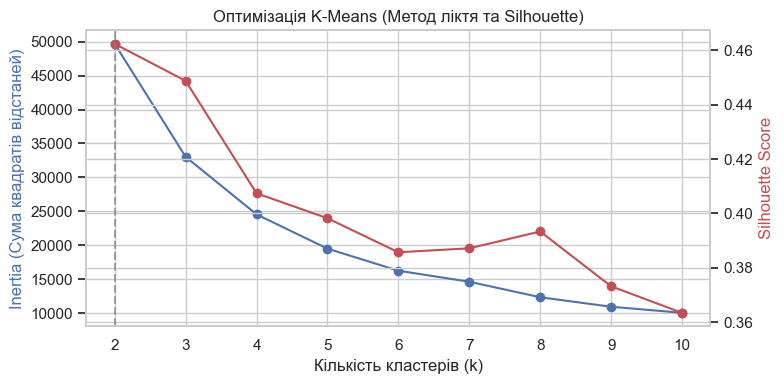

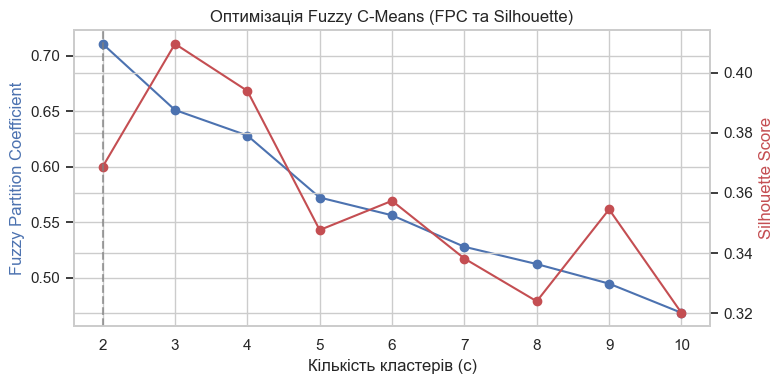

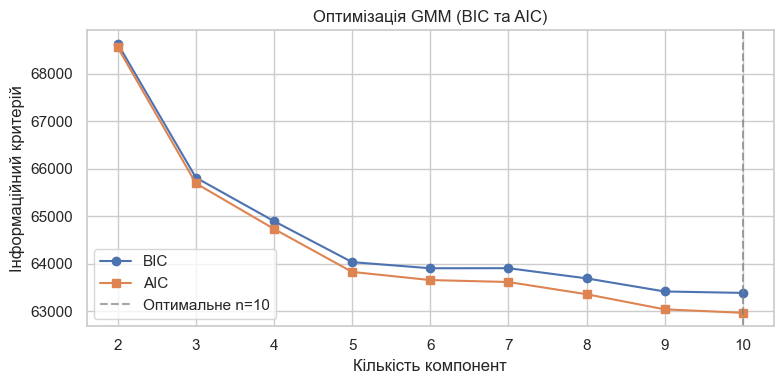

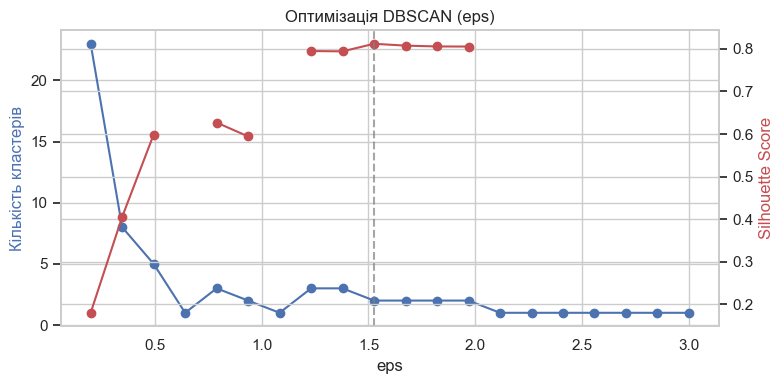

,Silhouette,Davies-Bouldin,Calinski-Harabasz,FPC
Model,,,,
K-Means (PCA 2),0.462377,1.002860,4098.929073,NaN
Fuzzy C-Means (PCA 2),0.368709,1.111621,3984.132429,0.710805
GMM (PCA 2),0.333547,0.941543,5094.810369,NaN
DBSCAN (PCA 2),0.811776,0.224349,549.332097,NaN


In [26]:
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(data)

explained_variance = pca_2.explained_variance_ratio_
total_variance = sum(explained_variance) * 100

print(f"Відсоток варіації, що пояснюється кожною компонентою: {explained_variance}")
print(f"Загальна пояснена варіація (сумарно для 2 компонент): {total_variance:.2f}%\n")

best_k_pca2 = optimize_kmeans(X_pca_2)
best_c_pca2 = optimize_fcm(X_pca_2)
best_n_gmm_pca2 = optimize_gmm(X_pca_2)
best_eps_pca2, best_min_pca2 = optimize_dbscan(X_pca_2, eps_range=np.linspace(0.2, 3.0, 20))
print()

pca2_metrics = []

kmeans_pca2 = KMeans(n_clusters=best_k_pca2, random_state=42, n_init='auto')
labels_kmeans_pca2 = kmeans_pca2.fit_predict(X_pca_2)
res_kmeans_pca2 = evaluate_clustering(X_pca_2, labels_kmeans_pca2, "K-Means (PCA 2)")
pca2_metrics.append(res_kmeans_pca2)

labels_fcm_pca2, _, fpc_pca2 = run_fuzzy_cmeans(X_pca_2, n_clusters=best_c_pca2)
res_fcm_pca2 = evaluate_clustering(X_pca_2, labels_fcm_pca2, "Fuzzy C-Means (PCA 2)", fuzzy_fpc=fpc_pca2)
pca2_metrics.append(res_fcm_pca2)

gmm_pca2 = GaussianMixture(n_components=best_n_gmm_pca2, random_state=42)
labels_gmm_pca2 = gmm_pca2.fit_predict(X_pca_2)
res_gmm_pca2 = evaluate_clustering(X_pca_2, labels_gmm_pca2, "GMM (PCA 2)")
pca2_metrics.append(res_gmm_pca2)

dbscan_pca2 = DBSCAN(eps=best_eps_pca2, min_samples=best_min_pca2)
labels_dbscan_pca2 = dbscan_pca2.fit_predict(X_pca_2)
res_dbscan_pca2 = evaluate_clustering(X_pca_2, labels_dbscan_pca2, "DBSCAN (PCA 2)")

if res_dbscan_pca2:
    pca2_metrics.append(res_dbscan_pca2)
else:
    print("DBSCAN (PCA 2): Неможливо обчислити метрики (забагато шуму або 1 кластер).")

results_pca2_df = pd.DataFrame(pca2_metrics).set_index("Model")
display(results_pca2_df)

**Результати кроку 3 (PCA з 2 компонентами).** Після зменшення розмірності до двох головних компонент усі метрики суттєво покращуються. Найвищий Silhouette у DBSCAN (0,812) та найнижчий Davies-Bouldin (0,22) — щільнісний метод добре виділяє компактні кластери в 2D. K-Means (0,462), FCM (0,369) та GMM (0,334) також мають значно кращі значення ніж без PCA; FPC для FCM зростає до 0,71. Два виміри достатні, щоб структура даних виявилася чіткіше, тому кластеризація стає ефективнішою.

<a id="pca_two"></a>
### 4. Зменшення розмірності за допомогою PCA (до 4–5 компонент)

Відсоток варіації, що пояснюється кожною компонентою: [0.27297671 0.2031378  0.08813182 0.07479524]
Загальна пояснена варіація (сумарно для 4 компонент): 63.90%



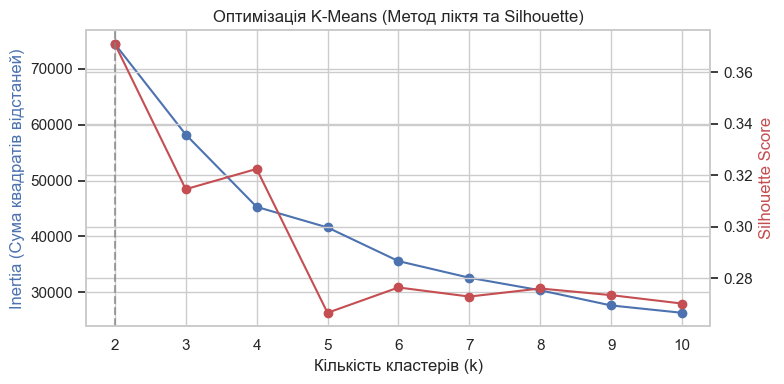

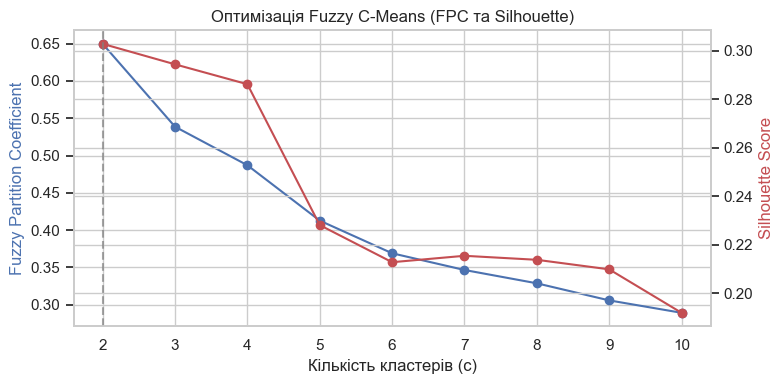

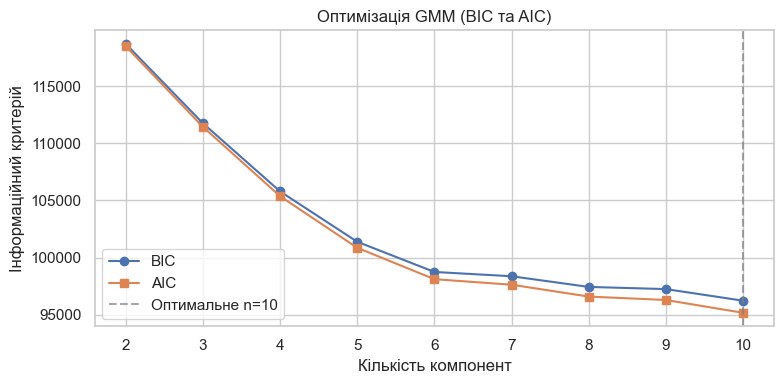

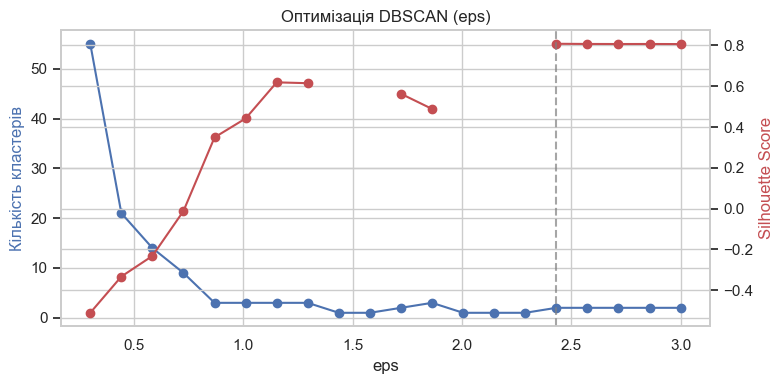


DBSCAN (PCA 4): Знайдено шумових точок: 54 з 8950


,Silhouette,Davies-Bouldin,Calinski-Harabasz,FPC
Model,,,,
K-Means (PCA 4),0.370920,1.286970,2740.574316,NaN
Fuzzy C-Means (PCA 4),0.302840,1.386286,2928.866190,0.64979
GMM (PCA 4),-0.017355,1.814108,1056.633931,NaN
DBSCAN (PCA 4),0.807979,0.215128,219.561533,NaN


In [27]:
pca_4 = PCA(n_components=4, random_state=42)
X_pca_4 = pca_4.fit_transform(data)

explained_variance_4 = pca_4.explained_variance_ratio_
total_variance_4 = sum(explained_variance_4) * 100

print(f"Відсоток варіації, що пояснюється кожною компонентою: {explained_variance_4}")
print(f"Загальна пояснена варіація (сумарно для 4 компонент): {total_variance_4:.2f}%\n")

best_k_pca4 = optimize_kmeans(X_pca_4)
best_c_pca4 = optimize_fcm(X_pca_4)
best_n_gmm_pca4 = optimize_gmm(X_pca_4)
best_eps_pca4, best_min_pca4 = optimize_dbscan(X_pca_4, eps_range=np.linspace(0.3, 3.0, 20))
print()

pca4_metrics = []

kmeans_pca4 = KMeans(n_clusters=best_k_pca4, random_state=42, n_init='auto')
labels_kmeans_pca4 = kmeans_pca4.fit_predict(X_pca_4)
res_kmeans_pca4 = evaluate_clustering(X_pca_4, labels_kmeans_pca4, "K-Means (PCA 4)")
pca4_metrics.append(res_kmeans_pca4)

labels_fcm_pca4, _, fpc_pca4 = run_fuzzy_cmeans(X_pca_4, n_clusters=best_c_pca4)
res_fcm_pca4 = evaluate_clustering(X_pca_4, labels_fcm_pca4, "Fuzzy C-Means (PCA 4)", fuzzy_fpc=fpc_pca4)
pca4_metrics.append(res_fcm_pca4)

gmm_pca4 = GaussianMixture(n_components=best_n_gmm_pca4, random_state=42)
labels_gmm_pca4 = gmm_pca4.fit_predict(X_pca_4)
res_gmm_pca4 = evaluate_clustering(X_pca_4, labels_gmm_pca4, "GMM (PCA 4)")
pca4_metrics.append(res_gmm_pca4)

dbscan_pca4 = DBSCAN(eps=best_eps_pca4, min_samples=best_min_pca4)
labels_dbscan_pca4 = dbscan_pca4.fit_predict(X_pca_4)

n_noise_pca4 = list(labels_dbscan_pca4).count(-1)
print(f"DBSCAN (PCA 4): Знайдено шумових точок: {n_noise_pca4} з {len(labels_dbscan_pca4)}")

res_dbscan_pca4 = evaluate_clustering(X_pca_4, labels_dbscan_pca4, "DBSCAN (PCA 4)")
if res_dbscan_pca4:
    pca4_metrics.append(res_dbscan_pca4)
else:
    print("DBSCAN (PCA 4): Неможливо обчислити метрики (забагато шуму або 1 кластер).")

results_pca4_df = pd.DataFrame(pca4_metrics).set_index("Model")
display(results_pca4_df)

**Результати кроку 4 (PCA з 4 компонентами).** У 4-вимірному PCA-просторі Silhouette для K-Means та FCM лишаються добрими (0,37 та 0,30), але нижчі за варіант з двома компонентами. GMM дає негативний Silhouette (−0,017) та високий Davies-Bouldin (1,81) — модель погано підходить до форми кластерів при чотирьох компонентах. DBSCAN знову дуже добрий (Silhouette 0,81, Davies-Bouldin 0,22). Висновок: для цього датасету збільшення числа компонент до чотирьох не покращує якість порівняно з двома й для частини методів навіть погіршує.

<a id="visualization"></a>
### 5. Візуалізація результатів

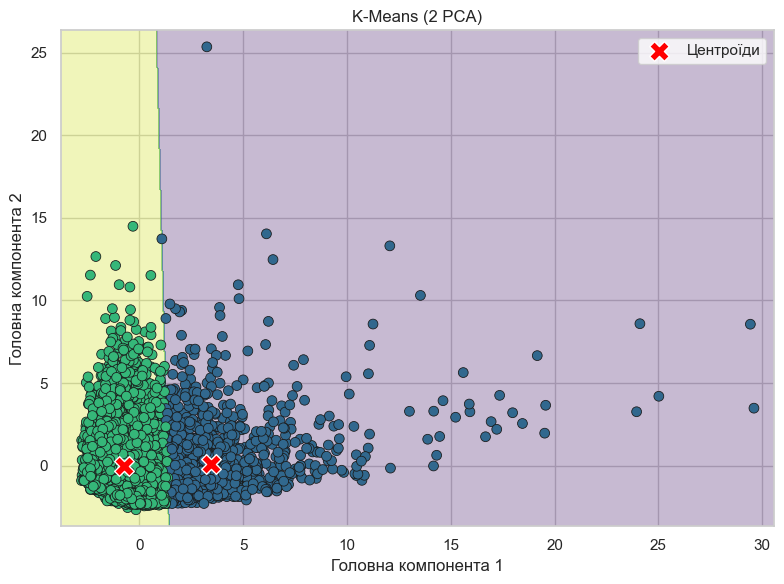

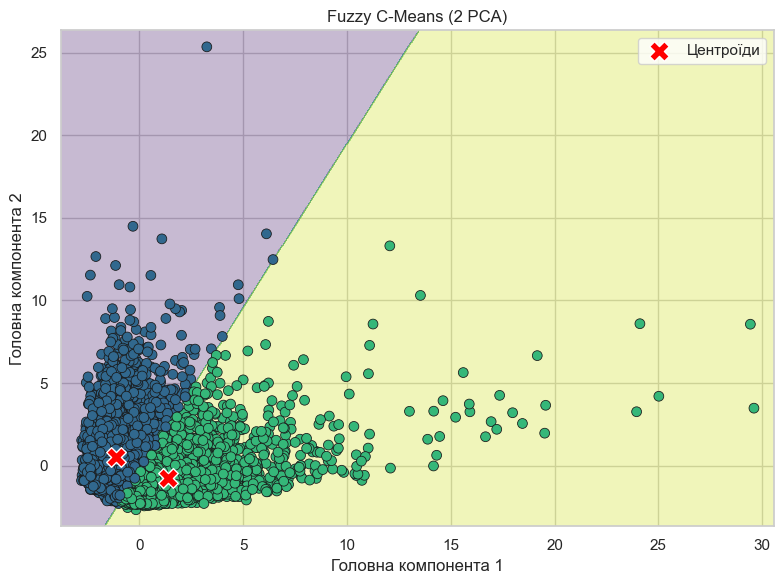

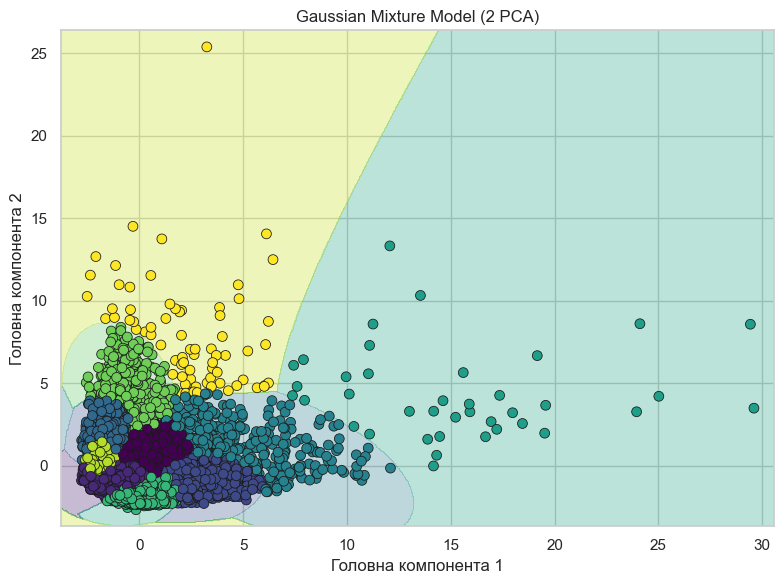

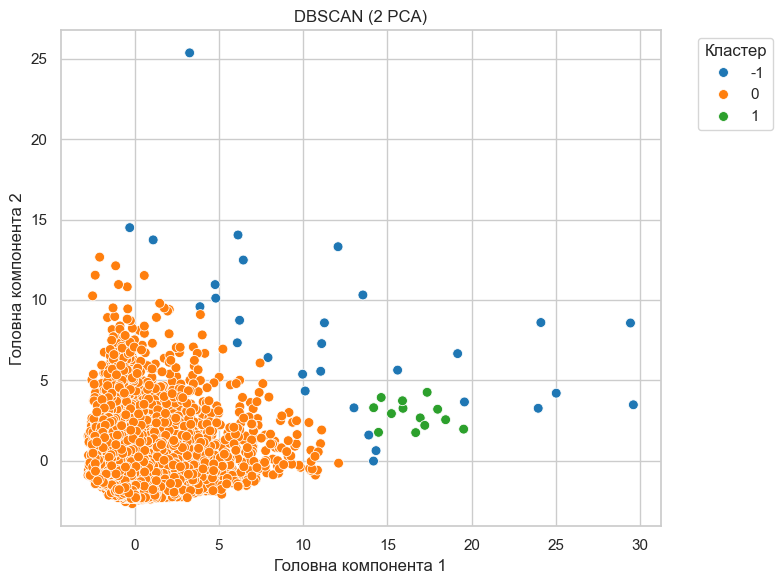

In [28]:
def plot_decision_boundaries(X, model, title, is_gmm=False, is_fcm=False, fcm_centers=None):
    plt.figure(figsize=(8, 6))
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    if is_gmm:
        Z = model.predict(grid_points)
    elif is_fcm and fcm_centers is not None:
        from scipy.spatial.distance import cdist
        distances = cdist(grid_points, fcm_centers)
        Z = np.argmin(distances, axis=1)
    else:
        Z = model.predict(grid_points)
        
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    
    if is_fcm:
        labels = labels_fcm_pca2
    else:
        labels = model.predict(X) if hasattr(model, 'predict') else model.fit_predict(X)
        
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="viridis", edgecolor="k", s=50, legend=False)
    
    if hasattr(model, 'cluster_centers_'):
        centers = model.cluster_centers_
        plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', edgecolor='white', label='Центроїди')
        plt.legend()
    elif is_fcm and fcm_centers is not None:
        plt.scatter(fcm_centers[:, 0], fcm_centers[:, 1], c='red', s=200, marker='X', edgecolor='white', label='Центроїди')
        plt.legend()
        
    plt.title(title)
    plt.xlabel('Головна компонента 1')
    plt.ylabel('Головна компонента 2')
    plt.tight_layout()
    plt.show()

plot_decision_boundaries(X_pca_2, kmeans_pca2, "K-Means (2 PCA)")

_, u_pca2, _ = run_fuzzy_cmeans(X_pca_2, n_clusters=best_c_fcm)
fcm_centers_pca2 = (X_pca_2.T @ (u_pca2 ** 2).T / np.sum(u_pca2 ** 2, axis=1)).T 
plot_decision_boundaries(X_pca_2, None, "Fuzzy C-Means (2 PCA)", is_fcm=True, fcm_centers=fcm_centers_pca2)

plot_decision_boundaries(X_pca_2, gmm_pca2, "Gaussian Mixture Model (2 PCA)", is_gmm=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=labels_dbscan_pca2, palette="tab10", s=50)
plt.title("DBSCAN (2 PCA)")
plt.xlabel('Головна компонента 1')
plt.ylabel('Головна компонента 2')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

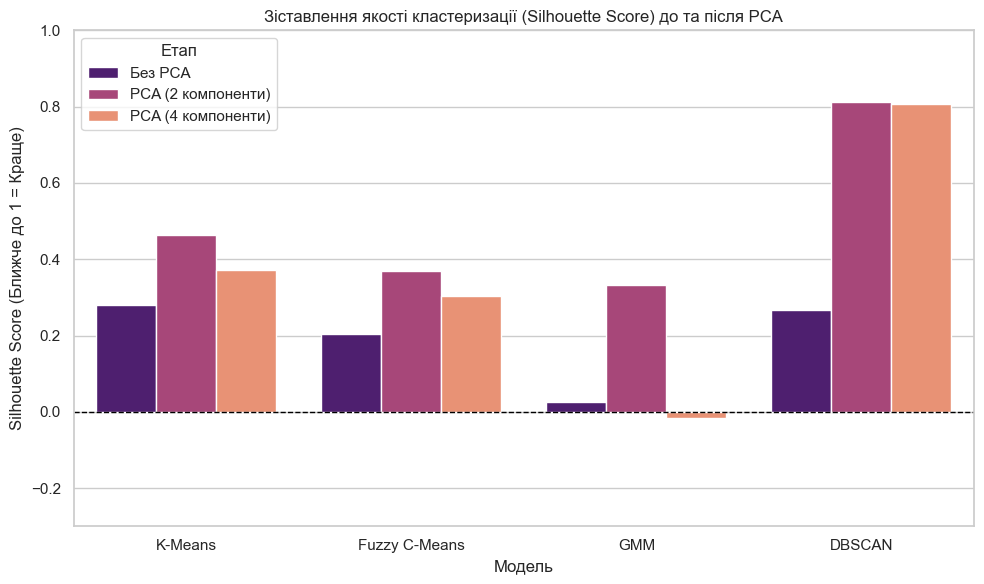

In [29]:
models = ['K-Means', 'Fuzzy C-Means', 'GMM', 'DBSCAN']

def get_sil(df, model_name):
    try:
        return df.loc[model_name, 'Silhouette']
    except (KeyError, TypeError):
        return np.nan

comparison_df = pd.DataFrame({
    'Модель': models,
    'Без PCA': [get_sil(results_df, m) for m in models],
    'PCA (2 компоненти)': [get_sil(results_pca2_df, f"{m} (PCA 2)") for m in models],
    'PCA (4 компоненти)': [get_sil(results_pca4_df, f"{m} (PCA 4)") for m in models]
})

comparison_melted = comparison_df.melt(id_vars='Модель', var_name='Етап', value_name='Silhouette Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Модель', y='Silhouette Score', hue='Етап', data=comparison_melted, palette='magma')
plt.title('Зіставлення якості кластеризації (Silhouette Score) до та після PCA')
plt.ylabel('Silhouette Score (Ближче до 1 = Краще)')
plt.ylim(-0.3, 1)
plt.axhline(0, color='black', linewidth=1, linestyle='--') 
plt.tight_layout()
plt.show()

<a id="analysis"></a>
### 6. Аналіз та висновки

In [30]:
df_base = results_df.reset_index().copy()
df_pca2 = results_pca2_df.reset_index().copy()
df_pca4 = results_pca4_df.reset_index().copy()

df_base['Етап'] = 'Без PCA'
df_pca2['Етап'] = 'PCA (2 комп.)'
df_pca4['Етап'] = 'PCA (4 комп.)'

df_pca2['Model'] = df_pca2['Model'].str.replace(r' \(PCA 2\)', '', regex=True)
df_pca4['Model'] = df_pca4['Model'].str.replace(r' \(PCA 4\)', '', regex=True)

final_combined_df = pd.concat([df_base, df_pca2, df_pca4], ignore_index=True)

models_order = ['K-Means', 'Fuzzy C-Means', 'GMM', 'DBSCAN']
stages_order = ['Без PCA', 'PCA (2 комп.)', 'PCA (4 комп.)']

final_combined_df['Model'] = pd.Categorical(final_combined_df['Model'], categories=models_order, ordered=True)
final_combined_df['Етап'] = pd.Categorical(final_combined_df['Етап'], categories=stages_order, ordered=True)

final_combined_df = final_combined_df.sort_values(['Model', 'Етап']).set_index(['Model', 'Етап'])

display(final_combined_df)

Silhouette  Davies-Bouldin  Calinski-Harabasz  \
Model         Етап                                                           
K-Means       Без PCA          0.279540        1.800894        1609.609316   
              PCA (2 комп.)    0.462377        1.002860        4098.929073   
              PCA (4 комп.)    0.370920        1.286970        2740.574316   
Fuzzy C-Means Без PCA          0.202929        1.922240        1689.602699   
              PCA (2 комп.)    0.368709        1.111621        3984.132429   
              PCA (4 комп.)    0.302840        1.386286        2928.866190   
GMM           Без PCA          0.024787        3.057064         413.377026   
              PCA (2 комп.)    0.333547        0.941543        5094.810369   
              PCA (4 комп.)   -0.017355        1.814108        1056.633931   
DBSCAN        Без PCA          0.267828        0.890272         642.460265   
              PCA (2 комп.)    0.811776        0.224349         549.332097   
              PCA (4 комп.)    0.807979        0.215128         219.561533   

                                  FPC  
Model         Етап                     
K-Means       Без PCA             NaN  
              PCA (2 комп.)       NaN  
              PCA (4 комп.)       NaN  
Fuzzy C-Means Без PCA        0.539522  
              PCA (2 комп.)  0.710805  
              PCA (4 комп.)  0.649790  
GMM           Без PCA             NaN  
              PCA (2 комп.)       NaN  
              PCA (4 комп.)       NaN  
DBSCAN        Без PCA             NaN  
              PCA (2 комп.)       NaN  
              PCA (4 комп.)       NaN

#### Підсумкова таблиця

Зведення показує, що для всіх моделей найкращі Silhouette та Davies-Bouldin досягаються після PCA з двома компонентами: K-Means 0,46, FCM 0,37, GMM 0,33, DBSCAN 0,81. Без PCA метрики найслабші; при переході до чотирьох компонент якість для K-Means і FCM трохи падає, а для GMM різко погіршується (негативний Silhouette). DBSCAN стабільно дає найкращі результати в знижено-вимірних просторах (2 та 4 компоненти), тоді як у вихідному 17D усі методи показують помірну якість через високу розмірність.

#### Обговорення впливу PCA

Зменшення розмірності за допомогою PCA суттєво вплинуло на якість кластеризації:

- **Без PCA** (вихідний простір, 17 ознак): Silhouette для всіх методів помірний або низький — найкращий у K-Means (0,28), далі DBSCAN (0,27) та FCM (0,20); GMM має дуже низький Silhouette (0,025) та найгірший Davies-Bouldin (3,06). Це підтверджує «прокляття розмірності»: у високовимірному просторі відстані менш інформативні, кластери виглядають розмитими.

- **PCA з 2 компонентами**: якість різко зростає. DBSCAN дає найвищий Silhouette (0,81) та найнижчий Davies-Bouldin (0,22); K-Means — 0,46 та 1,00; FCM — 0,37 та 1,11; GMM — 0,33 та 0,94. FPC для FCM підвищується до 0,71. Два головні напрямки варіації виявляються достатніми, щоб кластери стали чіткішими.

- **PCA з 4 компонентами**: DBSCAN лишається дуже добрим (Silhouette 0,81, Davies-Bouldin 0,22). K-Means та FCM трохи гірші за варіант з двома компонентами (0,37 та 0,30). GMM різко погіршується — Silhouette стає негативним (−0,017), Davies-Bouldin зростає до 1,81; модель погано описує форму кластерів у 4D. Додаткові компоненти не дають виграшу й для частини методів погіршують результат.

**Висновок:** для даного набору найкраща якість кластеризації досягається при **2 компонентах PCA** (найвищі Silhouette для K-Means, FCM, GMM; DBSCAN однаково сильний при 2 і 4 компонентах). Збільшення до 4 компонент не покращує метрики й для GMM призводить до погіршення.

#### Переваги та недоліки алгоритмів

- **K-Means:** Швидкий, простий, добре масштабується. 
  Плюси: зрозуміла інтерпретація (центроїди), стабільність при фіксованому k.
  Мінуси: потрібно задавати кількість кластерів; чутливий до початкової ініціалізації та викидів; припускає сферичні кластери приблизно однакового розміру.
- **Fuzzy C-Means (FCM):** Дає м’яке (нечітке) призначення об’єктів до кластерів (матриця приналежності). Плюси: корисний, коли об’єкти можуть належати кільком групам; FPC та інші метрики допомагають підбирати кількість кластерів. Мінуси: більш обчислювально витратний ніж K-Means; чутливий до параметра m та початкових центрів; так само орієнтований на опуклі кластери.
- **GMM:** Ймовірнісна модель, м’які призначення через ймовірності. Плюси: гнучкі форми кластерів (еліпсоїди); BIC/AIC для вибору кількості компонент; коректна ймовірнісна інтерпретація. Мінуси: потрібно задавати кількість компонент; чутливий до ініціалізації; при великій розмірності може бути нестійким без зменшення розмірності.
- **DBSCAN:** Не потребує задавати кількість кластерів, виявляє довільні форми та шум. Плюси: автоматичне виявлення числа кластерів; позначення викидів як шум (-1); стійкість до форми кластерів. Мінуси: чутливий до параметрів eps та min_samples; у високовимірному просторі часто дає багато шуму; якість сильно залежить від підбору eps (наприклад, сітковий пошук або візуалізація).

#### Загальний висновок

Для даного набору даних (кредитні картки) **найкращі результати за Silhouette та Davies-Bouldin дає DBSCAN після зменшення розмірності** (Silhouette ~0,81, Davies-Bouldin ~0,22 при 2 і 4 компонентах PCA) — щільнісний метод добре виділяє компактні кластери у знижено-вимірному просторі. **Другий за якістю — K-Means з PCA на 2 компоненти** (Silhouette 0,46, Davies-Bouldin 1,00). Fuzzy C-Means та GMM значно покращуються після PCA з 2 компонентами (FCM: Silhouette 0,37, FPC 0,71; GMM: 0,33), але при переході до 4 компонент GMM дає вже негативний Silhouette (−0,02), тоді як K-Means і FCM лишаються прийнятними.

На результати впливають: **розмірність** (у вихідному 17D усі метрики слабші), **число компонент PCA** (2 компоненти виявилися оптимальними; 4 не дають виграшу й погіршують GMM), та **тип алгоритму** (DBSCAN найкраще використовує просторову щільність після PCA; K-Means стабільний і зрозумілий; GMM чутливий до форми кластерів у 4D). Для сегментації клієнтів за цими ознаками практичний вибір — **PCA (2 компоненти) + DBSCAN** для максимальної якості або **PCA (2 компоненти) + K-Means** для простоти інтерпретації та центроїдів.